In [1]:
import torch
print(torch.__version__)

2.13.0+cpu


In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f'Using device ={device}')

Using device =cpu


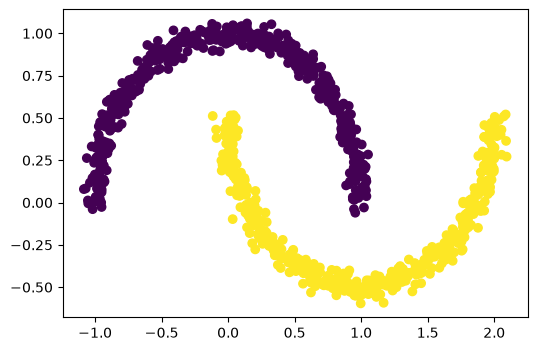

In [3]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
n_samples = 1000
X, y = make_moons(n_samples=n_samples,noise=0.04,random_state=42)
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=y);
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from torch import nn
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10,out_features=1)
        self.relu = nn.ReLU()
        
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [6]:
torch.manual_seed(42)
model = NeuralNetwork()
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [7]:
n_of_params = 0
state_dict = model.state_dict()
for param in state_dict.keys():
    if len(state_dict[param].size()) == 1:
        n_of_params = n_of_params + state_dict[param].size()[0]
    else:
        n_of_params = n_of_params + state_dict[param].size()[0]*state_dict[param].size()[1]
        
print(n_of_params)

151


In [8]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [9]:
def accuracy_fn(y_actual, y_pred):
    correct = torch.eq(y_actual, y_pred).sum().item()
    acc = (correct/len(y_actual))*100
    return acc

In [10]:
epochs = 5000
train_loss_list = []
test_loss_list = []
model.to(device)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    
    #### TRAINING
    model.train()
    
    # 1. FORWARD PASS
    train_logits = model(X_train).squeeze()
    train_preds = torch.round(torch.sigmoid(train_logits))
    train_loss = loss_fn(train_logits, y_train)
    train_acc = accuracy_fn(y_actual=y_train, y_pred=train_preds)
    #  ZERO GRADE OPTIMIZER
    optimizer.zero_grad()
    # COMPUTE THE GRADIENT
    train_loss.backward()
    # # UPDATE THE WEIGHT 
    optimizer.step()
    # TESTING
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_actual=y_test, y_pred=test_preds)
    train_loss_list.append(train_loss.item())
    test_loss_list.append(test_loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}|Loss {train_loss:.5f}|Acc {train_acc:.2f}|Test Loss {test_loss:.5f}|Test Acc {test_acc:.2f}')
    
    
    

Epoch 100|Loss 0.68205|Acc 76.62|Test Loss 0.68326|Test Acc 71.50
Epoch 200|Loss 0.66779|Acc 79.50|Test Loss 0.67034|Test Acc 76.50
Epoch 300|Loss 0.65035|Acc 77.75|Test Loss 0.65449|Test Acc 74.00
Epoch 400|Loss 0.62531|Acc 76.12|Test Loss 0.63173|Test Acc 69.00
Epoch 500|Loss 0.59197|Acc 75.25|Test Loss 0.60139|Test Acc 71.00
Epoch 600|Loss 0.55089|Acc 76.12|Test Loss 0.56324|Test Acc 72.50
Epoch 700|Loss 0.50498|Acc 77.38|Test Loss 0.51994|Test Acc 74.50
Epoch 800|Loss 0.45900|Acc 78.38|Test Loss 0.47589|Test Acc 74.50
Epoch 900|Loss 0.41836|Acc 80.38|Test Loss 0.43629|Test Acc 75.50
Epoch 1000|Loss 0.38518|Acc 82.00|Test Loss 0.40309|Test Acc 76.50
Epoch 1100|Loss 0.35852|Acc 83.12|Test Loss 0.37547|Test Acc 78.50
Epoch 1200|Loss 0.33657|Acc 84.12|Test Loss 0.35200|Test Acc 80.00
Epoch 1300|Loss 0.31801|Acc 85.00|Test Loss 0.33153|Test Acc 81.00
Epoch 1400|Loss 0.30193|Acc 85.88|Test Loss 0.31339|Test Acc 82.00
Epoch 1500|Loss 0.28779|Acc 86.38|Test Loss 0.29718|Test Acc 85.00
Epoc

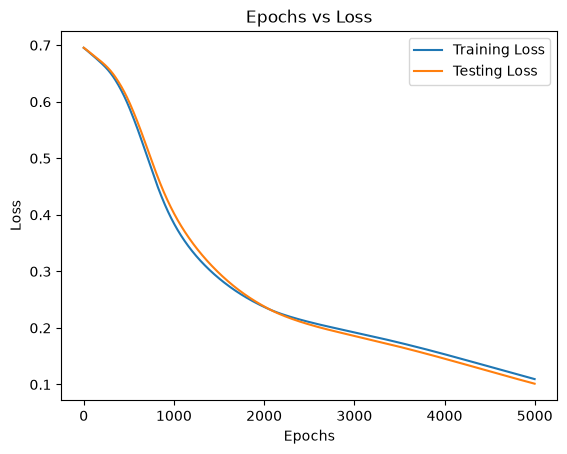

In [11]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Epochs vs Loss");

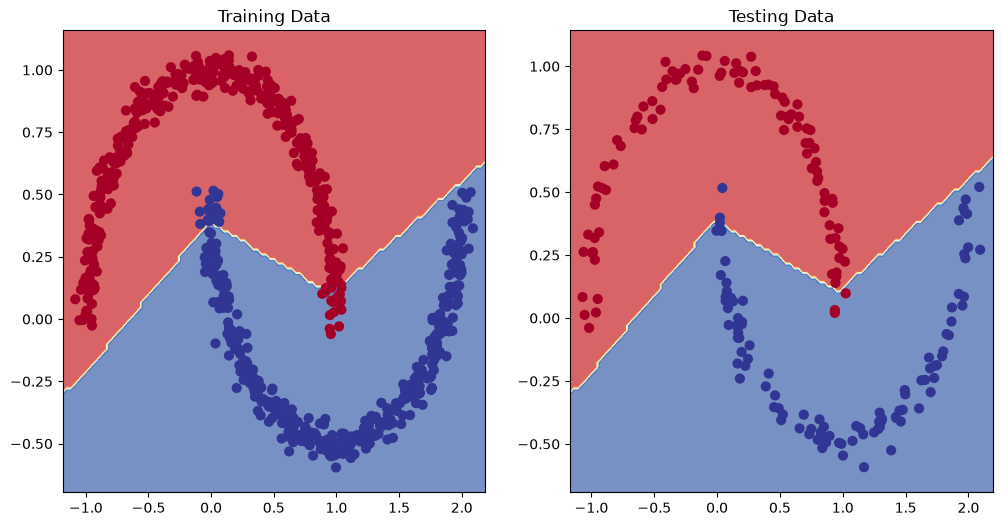

In [12]:
from helper_function import plot_decision_boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)